# Sky-position scan with NITRATES

This notebook performs a **minimal non-imaging sky scan** over a few trial positions and computes $\sqrt{TS}$ at each position.

## What this notebook does
1. Load the bundled test dataset from `tests/nitrates_resp_dir` (or `NITRATES_RESP_DIR` if already set).
2. Build source + background likelihood objects.
3. Scan a small set of sky positions around a reference RA/Dec.
4. Profile over signal amplitude $A$ at each position and compute:

$$\sqrt{TS} = \sqrt{2(\mathrm{NLLH}_{\mathrm{bkg}} - \mathrm{NLLH}_{\mathrm{sig+bkg}})}$$

5. Show a sky localization map

In [1]:
import os

# ── macOS kernel-crash prevention ────────────────────────────────────────────
# These MUST be set before ANY library that links OpenMP / MKL / Accelerate
# is imported.  The root cause is that macOS loads multiple OpenMP runtimes
# simultaneously (libomp from conda-forge + libiomp5 from Intel/MKL), which
# corrupts Numba's JIT thread pool and causes a hard segfault.
#
# Key fix: switch Numba away from OpenMP entirely → use its own work-queue.
os.environ['NUMBA_THREADING_LAYER']    = 'workqueue'   # ← the essential fix
os.environ['NUMBA_NUM_THREADS']        = '1'
os.environ['OMP_NUM_THREADS']          = '1'
os.environ['MKL_NUM_THREADS']          = '1'
os.environ['OPENBLAS_NUM_THREADS']     = '1'
os.environ['VECLIB_MAXIMUM_THREADS']   = '1'           # macOS Accelerate
os.environ['KMP_DUPLICATE_LIB_OK']     = 'TRUE'        # last-resort guard
# ─────────────────────────────────────────────────────────────────────────────

import logging
from pathlib import Path
import numpy as np
from astropy.io import fits
from nitrates.lib import (
    get_conn,
    get_info_tab,
    mask_detxy,
    convert_radec2thetaphi,
    convert_theta_phi2radec,
)
from nitrates.response import RayTraces
from nitrates.models import (
    Cutoff_Plaw_Flux,
    Source_Model_InOutFoV,
    CompoundModel,
    Sig_Bkg_Model,
    get_eflux_from_model,
)
from nitrates.llh_analysis import parse_bkg_csv, LLH_webins2, NLLH_ScipyMinimize_Wjacob

logging.basicConfig(level=logging.WARNING)

# Use the explicit local response directory
resp_dir = Path('/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir').resolve()
if not resp_dir.exists():
    raise FileNotFoundError(f'NITRATES response directory not found: {resp_dir}')

os.environ['NITRATES_RESP_DIR'] = str(resp_dir)
rt_dir = resp_dir / 'ray_traces_detapp_npy'
solid_angle_dpi_path = resp_dir / 'solid_angle_dpi.npy'

print(f"Using responses from: {resp_dir}")


Could not get the $HEADAS system variable. Please ensure that this is set and points to the HEASOFT directory.
Could not get the $CALDB system variable. Please ensure that this is set and points to the CALDB directory.
No module named 'ROOT'
Please install the Python ROOT package to be able to run the full forward modeling calculations.
16
16
[array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]), array([19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]), array([37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]), array([55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68]), array([73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86]), array([ 91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104]), array([109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121,
       122]), array([127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139,
       140]), array([145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157,

/opt/anaconda3/envs/nitrates_env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [2]:

trigid = '785996578_c0'
triggertime = '2025-11-28T04:22:21.610000'

# Define the literature/source sky position used throughout the tutorial.
source_ra_dec = (123, 50)

root = '/Users/samueleronchini/Desktop/nitrates_tutorial'

workdir = f'{root}/{trigid}'

In [3]:
# Trigger metadata
conn = get_conn(workdir + '/results.db')
info_tab = get_info_tab(conn)
trig = info_tab['trigtimeMET'][0]

# Event data and detector mask
ev_data = fits.open(workdir + '/filter_evdata.fits')[1].data
dmask = fits.open(workdir + '/detmask.fits')[0].data
mask_vals = mask_detxy(dmask, ev_data)
bl_dmask = dmask == 0.0

# Basic time/energy cuts
t_start = trig - 20
t_end = trig + 20
bl_ev = (
    (ev_data['EVENT_FLAGS'] < 1)
    & (ev_data['ENERGY'] <= 500.0)
    & (ev_data['ENERGY'] >= 14.0)
    & (mask_vals == 0.0)
    & (ev_data['TIME'] <= t_end)
    & (ev_data['TIME'] >= t_start)
)
filtered_ev_data = ev_data[bl_ev]
print(f"Selected {len(filtered_ev_data)} events over {t_end - t_start:.1f} s")


Selected 169204 events over 40.0 s


In [4]:
# Build the analysis energy bins in keV.
# `ebins0` contains the lower edge of each bin and `ebins1` the matching upper edge.
ebins0 = np.array([15.0, 24.0, 35.0, 48.0, 64.0])
ebins0 = np.append(ebins0, np.logspace(np.log10(84.0), np.log10(500.0), 5 + 1))[:-1]
ebins0 = np.round(ebins0, decimals=1)[:-1]
ebins1 = np.append(ebins0[1:], [350.0])

# Load the spacecraft attitude table and select the quaternion closest to the trigger time.
# This quaternion describes how the instrument was oriented on the sky at that moment.
attfile = fits.open(workdir + '/attitude.fits')[1].data
att_ind = np.argmin(np.abs(attfile['TIME'] - trig))
att_quat = attfile['QPARAM'][att_ind]

# Convert the source sky coordinates (RA, Dec) into instrument coordinates (theta, phi).
# The source response must be evaluated in the detector frame, not directly in RA/Dec.
theta, phi = convert_radec2thetaphi(*source_ra_dec, att_quat)

# Configure the spectral model parameters used as the initial source hypothesis.
# `A` is the normalization, `gamma` the photon index, and `Epeak` the cutoff/peak scale in keV.
flux_params = {'A': 1.0, 'gamma': 0.5, 'Epeak': 1e2}
flux_mod = Cutoff_Plaw_Flux(E0=100.0)

# Load the precomputed ray traces that encode detector shadowing across the field of view.
rt_obj = RayTraces(rt_dir)

# Build the non-imaging source model using the spectral model, energy bins, detector mask,
# ray traces, and the response tables bundled with the tutorial dataset.
sig_mod = Source_Model_InOutFoV(
    flux_mod,
    [ebins0, ebins1],
    bl_dmask,
    rt_obj,
    use_deriv=True,
    resp_tab_dname=resp_dir/'resp_tabs_ebins',
    comp_flor_resp_dname=resp_dir/'comp_flor_resps',
    hp_flor_resp_dname=resp_dir/'hp_flor_resps',
)

# Apply the instrument-frame sky position and spectral parameters to the source model.
sig_mod.set_theta_phi(theta, phi)
sig_mod.set_flux_params(flux_params)

# Print a compact summary so we can verify the selected attitude sample and derived geometry.
print(f"Pointing quaternion index: {att_ind}")
print(f"Theta/Phi (deg): {theta:.3f}, {phi:.3f}")

(0.0, 30.48, -14.117)
(0.0, 30.48, -14.117)
(45.0, 54.0)
35.59031462549889
35.59031462549889


/Users/samueleronchini/Desktop/NITRATES/nitrates/response/response.py:1617: RuntimeWarning: invalid value encountered in divide


initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_45.0_phi_30.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_45.0_phi_45.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_54.0_phi_30.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_54.0_phi_45.0_.fits
Pointing quaternion index: 175
Theta/Phi (deg): 52.335, 125.590


This cell prepares the source/background setup and **chooses the analysis time bin from** time_seeds.csv.

1. Loads attitude at trigger time and keeps the reference sky position.
2. Reads time_seeds.csv from the working directory.
3. Selects the best temporal seed (priority: snr, then TS, then $\sqrt{TS}$).
4. Converts the selected seed to absolute interval $[t_0, t_1]$.
5. Loads bkg_estimation.csv and extracts background parameters at the interval midpoint.
6. Builds reusable likelihood/model objects with the selected time window.

After this cell, all sky-position scans use the same best temporal bin from the seed file.

In [5]:
# --- Build source model ingredients and background model ---
# Attitude quaternion nearest trigger (needed for RA/Dec -> theta/phi conversion).
import glob
import pandas as pd

att = fits.open(resp_dir / 'attitude.fits')[1].data
att_idx = int(np.argmin(np.abs(att['TIME'] - trig)))
att_quat = att['QPARAM'][att_idx]

# Reference source position (can be changed if desired).
ra_ref, dec_ref = source_ra_dec[0], source_ra_dec[1]

# Choose analysis time bin from time_seeds.csv (best seed).
time_seeds_path = Path(workdir) / 'time_seeds.csv'
if not time_seeds_path.exists():
    raise FileNotFoundError(f'time_seeds.csv not found: {time_seeds_path}')

time_seeds_df = pd.read_csv(time_seeds_path)
dur_col = 'duration' if 'duration' in time_seeds_df.columns else ('dur' if 'dur' in time_seeds_df.columns else None)
if dur_col is None:
    raise KeyError("time_seeds.csv must contain 'duration' (or 'dur')")

# Prefer full-rates ranking if present.
if 'snr' in time_seeds_df.columns:
    best_seed_idx = time_seeds_df['snr'].astype(float).idxmax()
elif 'TS' in time_seeds_df.columns:
    best_seed_idx = time_seeds_df['TS'].astype(float).idxmax()
elif 'sqrtTS' in time_seeds_df.columns:
    best_seed_idx = time_seeds_df['sqrtTS'].astype(float).idxmax()
else:
    raise KeyError("time_seeds.csv must contain one ranking column among: 'snr', 'TS', 'sqrtTS'")

best_seed = time_seeds_df.loc[best_seed_idx]
dur_best = float(best_seed[dur_col])

if 'time' in time_seeds_df.columns:
    t0 = float(best_seed['time'])
elif 'dt' in time_seeds_df.columns:
    t0 = float(trig) + float(best_seed['dt'])
else:
    raise KeyError("time_seeds.csv must contain either 'time' or 'dt'")
t1 = t0 + dur_best

print(
    f"Selected best time seed from {time_seeds_path.name}: "
    f"t0-trig={t0 - float(trig):+.3f} s, dur={dur_best:.3f} s"
)

# Spectral shape: take gamma/Epeak from split-rates results (same or nearest time bin).
split_files = sorted(glob.glob(str(Path(workdir) / 'rates_llh_res_*.csv')))
if not split_files:
    raise FileNotFoundError('No split-rate files found (rates_llh_res_*.csv). Run split-rates first.')

split_df = pd.concat([pd.read_csv(f) for f in split_files], ignore_index=True)
if 'gamma' not in split_df.columns or 'Epeak' not in split_df.columns:
    raise KeyError("Split-rate table must contain 'gamma' and 'Epeak' columns")

# Match split-rates row to selected time seed.
cand = split_df.copy()

# Prefer exact match by timeID if available in both tables.
if 'timeID' in cand.columns and 'timeID' in best_seed.index:
    cand = cand[cand['timeID'].astype(float) == float(best_seed['timeID'])]

# If timeID match is empty/not available, use nearest in (time, duration).
if len(cand) == 0:
    if 'time' in split_df.columns and 'dur' in split_df.columns:
        tmp = split_df.copy()
        tmp['_metric'] = (tmp['time'].astype(float) - float(t0)).abs() + (tmp['dur'].astype(float) - float(dur_best)).abs()
        min_metric = float(tmp['_metric'].min())
        cand = tmp[tmp['_metric'] == min_metric].copy()
    else:
        cand = split_df.copy()

# Choose highest-significance split-rate row among candidates.
rank_col = 'TS' if 'TS' in cand.columns else ('sqrtTS' if 'sqrtTS' in cand.columns else None)
if rank_col is not None:
    best_split = cand.loc[cand[rank_col].astype(float).idxmax()]
else:
    best_split = cand.iloc[0]

gamma_best = float(best_split['gamma'])
epeak_best = float(best_split['Epeak'])

flux_mod = Cutoff_Plaw_Flux(E0=100.0)
flux_shape = {'A': 1.0, 'gamma': gamma_best, 'Epeak': epeak_best}
print(f"Using split-rates spectral shape: gamma={gamma_best:.3f}, Epeak={epeak_best:.2f} keV")

# Background model and parameters at analysis time midpoint.
bkg_csv_path = Path(workdir) / 'bkg_estimation.csv'

bkg_df, bkg_name, _, bkg_mod, ps_mods = parse_bkg_csv(
    bkg_csv_path,
    np.load(solid_angle_dpi_path),
    ebins0,
    ebins1,
    bl_dmask,
    rt_dir,
)

tmid = 0.5 * (t0 + t1)
bkg_row = bkg_df.iloc[np.argmin(np.abs(bkg_df['time'] - tmid))]

# Some background CSV files store columns with a prefix (e.g. "Background_bkg_rate_0")
# while model parameter names may be unprefixed (e.g. "bkg_rate_0").
def _get_bkg_value(row, pname, prefix):
    if pname in row.index:
        return row[pname]

    pref_name = f"{prefix}{pname}" if prefix else pname
    if pref_name in row.index:
        return row[pref_name]

    if pname.startswith('Background_'):
        no_pref = pname[len('Background_'):]
        if no_pref in row.index:
            return row[no_pref]

    raise KeyError(f"Background parameter '{pname}' not found in CSV columns")

bkg_params = {p: _get_bkg_value(bkg_row, p, bkg_name) for p in bkg_mod.param_names}

# Reusable objects that do not depend on trial sky position.
rt_obj = RayTraces(rt_dir)
llh = LLH_webins2(filtered_ev_data, ebins0, ebins1, bl_dmask, has_err=True)
llh.set_time(t0, t1)

print('Source/background setup complete.')

Selected best time seed from time_seeds.csv: t0-trig=-1.024 s, dur=4.096 s
Using split-rates spectral shape: gamma=-0.100, Epeak=411.33 keV
[]
Source/background setup complete.


### `eval_sky_position`

This helper evaluates one trial sky coordinate and returns the detection significance for that point.

1. Receives trial $(\mathrm{RA},\mathrm{Dec})$ and clips/wraps values to valid ranges.
2. Converts sky coordinates to instrument coordinates $(\theta,\phi)$ using the trigger-time attitude.
3. Builds a trial source model at that sky position with fixed spectral shape.
4. Combines source + background models and attaches them to the likelihood object.
5. Computes background-only NLLH with $A\approx 0$.
6. Profiles the likelihood over amplitude `A` (all other parameters fixed).
7. Computes $\sqrt{TS}=\sqrt{2(\mathrm{NLLH}_{\mathrm{bkg}}-\mathrm{NLLH}_{\mathrm{best}})}$ and returns a result dictionary.

Returned fields include position, best-fit amplitude, NLLH values, and `sqrtTS`.

In [6]:
# --- Helper: evaluate one sky position and return sqrtTS ---
def eval_sky_position(ra_deg: float, dec_deg: float):
    """
    Evaluate one trial (RA, Dec):
    1) Convert to instrument coordinates (theta, phi).
    2) Build source+background model with fixed spectral shape.
    3) Profile likelihood over amplitude A only.
    4) Compute sqrtTS relative to background-only hypothesis.
    """
    # Keep values in physical ranges for robust scanning.
    ra_deg = float(ra_deg % 360.0)
    dec_deg = float(np.clip(dec_deg, -89.0, 89.0))

    # Sky -> instrument frame.
    theta, phi = convert_radec2thetaphi(ra_deg, dec_deg, att_quat)

    # Build trial source model at this sky location.
    sig_mod = Source_Model_InOutFoV(
        flux_mod,
        [ebins0, ebins1],
        bl_dmask,
        rt_obj,
        use_deriv=True,
        resp_tab_dname=resp_dir / 'resp_tabs_ebins',
        comp_flor_resp_dname=resp_dir / 'comp_flor_resps',
        hp_flor_resp_dname=resp_dir / 'hp_flor_resps',
    )
    sig_mod.set_theta_phi(float(theta), float(phi))
    sig_mod.set_flux_params(flux_shape)

    # Combine source + background and set parameters.
    sig_bkg = Sig_Bkg_Model(bl_dmask, sig_mod, bkg_mod, use_deriv=True)
    sig_bkg.set_bkg_params(bkg_params)
    sig_bkg.set_sig_params({
        'A': 1.0,
        'gamma': float(flux_shape['gamma']),
        'Epeak': float(flux_shape['Epeak']),
        'theta': float(theta),
        'phi': float(phi),
    })

    # Attach model to LLH object.
    llh.set_model(sig_bkg)

    # Background-only NLLH (A ~ 0).
    nllh_bkg = -float(llh.get_logprob({'A': 1e-10}))

    # Profile over A with all other parameters fixed.
    miner = NLLH_ScipyMinimize_Wjacob('')
    miner.set_llh(llh)
    miner.set_fixed_params(miner.param_names, fixed=True)
    miner.set_fixed_params(['A'], fixed=False)

    bf_vals, nllh_vals, _ = miner.minimize()
    A_best = float(np.atleast_1d(bf_vals[0])[0])
    nllh_best = float(nllh_vals[0])

    # sqrtTS from profile likelihood ratio.
    sqrt_ts = float(np.sqrt(max(2.0 * (nllh_bkg - nllh_best), 0.0)))

    return {
        'ra': ra_deg,
        'dec': dec_deg,
        'theta': float(theta),
        'phi': float(phi),
        'A_best': A_best,
        'nllh_bkg': nllh_bkg,
        'nllh_best': nllh_best,
        'sqrtTS': sqrt_ts,
    }

In [7]:
import pandas as pd

# --- Define a 3×3 grid of trial sky positions around the reference point ---
offsets = np.linspace(-35, 35, 4)
trial_positions = [
    (ra_ref + dra, dec_ref + ddec)
    for ddec in offsets
    for dra in offsets
]

rows = []
for ra_i, dec_i in trial_positions:
    try:
        rows.append(eval_sky_position(ra_i, dec_i))
    except Exception as e:
        # If one position is unsupported by response coverage, continue scanning others.
        rows.append({
            'ra': float(ra_i),
            'dec': float(dec_i),
            'theta': np.nan,
            'phi': np.nan,
            'A_best': np.nan,
            'nllh_bkg': np.nan,
            'nllh_best': np.nan,
            'sqrtTS': np.nan,
            'error': str(e),
        })

scan_df = pd.DataFrame(rows)
scan_df = scan_df.sort_values('sqrtTS', ascending=False, na_position='last').reset_index(drop=True)

display_cols = ['ra', 'dec', 'A_best', 'sqrtTS', 'nllh_bkg', 'nllh_best']
print('Sky scan results (sorted by sqrtTS):')
display(scan_df[display_cols])

if scan_df['sqrtTS'].notna().any():
    best = scan_df.loc[scan_df['sqrtTS'].idxmax()]
    print(
        f"Best trial position: RA={best['ra']:.3f}, Dec={best['dec']:.3f}, "
        f"sqrtTS={best['sqrtTS']:.3f}, A_best={best['A_best']:.3e}"
    )
else:
    print('No valid sky points were evaluated.')


(0.0, 30.48, -14.117)
(0.0, 30.48, -14.117)


/Users/samueleronchini/Desktop/NITRATES/nitrates/response/response.py:1617: RuntimeWarning: invalid value encountered in divide


(63.0, 72.0)
33.717838404782015
11.282161595217985
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_63.0_phi_0.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_63.0_phi_15.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_72.0_phi_0.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_72.0_phi_15.0_.fits


(0.0, 30.48, -14.117)
(0.0, 30.48, -14.117)
(36.0, 45.0)
21.476676602570535
23.523323397429465
max rt: 11579.5469
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_36.0_phi_15.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_36.0_phi_30.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_45.0_phi_15.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_45.0_phi_30.0_.fits
(0.0, 30.48, -14.117)
(0.0, 30.48, -14.117)
(18.0, 27.0)
0.23358637578198227
44.76641362421802


max rt: 9482.4775
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_18.0_phi_30.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_18.0_phi_45.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_27.0_phi_30.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_27.0_phi_45.0_.fits
(0.0, 30.48, -14.117)
(0.0, 30.48, -14.117)
(9.0, 18.0)
27.57411664722798
17.42588335277202


...

(54.0, 63.0)
25.796727099852205
19.203272900147795
max rt: 179698.3281
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_54.0_phi_15.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_54.0_phi_30.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_63.0_phi_15.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_63.0_phi_30.0_.fits


(0.0, 30.48, -14.117)
(0.0, 30.48, -14.117)
(54.0, 63.0)
27.754533602557387
17.245466397442613
max rt: 161413.0469
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_54.0_phi_15.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_54.0_phi_30.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_63.0_phi_15.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_63.0_phi_30.0_.fits


(0.0, 30.48, -14.117)
(0.0, 30.48, -14.117)
(54.0, 63.0)
30.14959002791278
14.85040997208722
max rt: 149286.1562
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_54.0_phi_0.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_54.0_phi_15.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_63.0_phi_0.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_63.0_phi_15.0_.fits
Sky scan results (sorted by sqrtTS):


,ra,dec,A_best,sqrtTS,nllh_bkg,nllh_best
0,88.000000,15.000000,0.010049,16.570776,51767.325646,51630.030332
1,158.000000,38.333333,0.006979,16.276956,51767.325645,51634.855998
2,111.333333,15.000000,0.006873,16.210564,51767.325645,51635.934451
3,88.000000,85.000000,0.006788,15.747367,51767.325645,51643.335867
4,111.333333,85.000000,0.006873,15.540036,51767.325645,51646.579283
5,134.666667,61.666667,0.008508,15.536782,51767.325646,51646.629841
6,158.000000,61.666667,0.007042,15.471196,51767.325645,51647.646686
7,158.000000,85.000000,0.006715,15.458336,51767.325645,51647.845566
8,158.000000,15.000000,0.005905,15.428516,51767.325645,51648.306096
9,134.666667,85.000000,0.006800,15.363699,51767.325645,51649.304018


Best trial position: RA=88.000, Dec=15.000, sqrtTS=16.571, A_best=1.005e-02


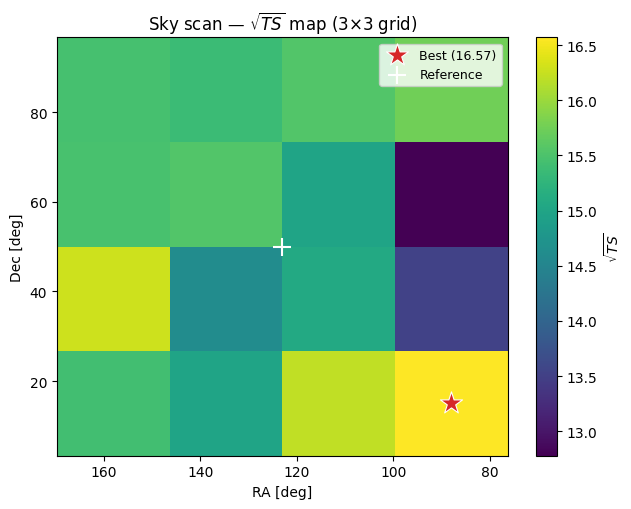

In [8]:
# --- 2D map: sqrtTS on the RA/Dec grid ---
import matplotlib.pyplot as plt
import numpy as np

valid = scan_df['sqrtTS'].notna()
if valid.any():
    df_v = scan_df.loc[valid].copy()

    # Reconstruct the 2D grid (RA increases left → invert x-axis later)
    ra_vals  = np.sort(df_v['ra'].unique())
    dec_vals = np.sort(df_v['dec'].unique())

    grid = np.full((len(dec_vals), len(ra_vals)), np.nan)
    ra_idx  = {v: i for i, v in enumerate(ra_vals)}
    dec_idx = {v: i for i, v in enumerate(dec_vals)}
    for _, row in df_v.iterrows():
        grid[dec_idx[row['dec']], ra_idx[row['ra']]] = row['sqrtTS']

    fig, ax = plt.subplots(figsize=(6.5, 5.2))
    im = ax.pcolormesh(
        ra_vals, dec_vals, grid,
        cmap='viridis', shading='nearest',
    )
    plt.colorbar(im, ax=ax, label=r'$\sqrt{TS}$')

    # Mark best position
    best = scan_df.loc[scan_df['sqrtTS'].idxmax()]
    ax.scatter(
        best['ra'], best['dec'],
        marker='*', s=280, color='tab:red',
        edgecolors='white', linewidths=0.8,
        zorder=5, label=f"Best ({best['sqrtTS']:.2f})",
    )

    # Mark reference position
    ax.scatter(
        [ra_ref], [dec_ref],
        marker='+', s=160, color='white',
        linewidths=1.5, zorder=5, label='Reference',
    )

    ax.set_xlabel('RA [deg]')
    ax.set_ylabel('Dec [deg]')
    ax.set_title(r'Sky scan — $\sqrt{TS}$ map (3×3 grid)')
    ax.invert_xaxis()
    ax.legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print('No valid points to plot.')


## Notes
- This is intentionally minimal: it scans only **5 trial positions**.
- Spectral shape (`gamma`, `Epeak`) is fixed; only amplitude $A$ is profiled.
- To increase localization detail, enlarge the trial grid (more RA/Dec offsets).
- If some trial points fail, they are reported as NaN (typically response-coverage limits).

## Extra section: max TS on a joint sky + spectral grid

In this final section we do a compact **joint grid scan** over:
- sky positions (RA/Dec around the reference), and
- spectral shape parameters (`gamma`, `Epeak`).

For each grid point we:
1. Build the source model at that sky position.
2. Fix (`gamma`, `Epeak`) to trial values.
3. Profile only over amplitude `A`.
4. Compute `TS = 2(\mathrm{NLLH}_{bkg} - \mathrm{NLLH}_{sig+bkg})` and `sqrtTS`.

This is slower than the essential scan, so the default grids below are intentionally small.

In [9]:
# --- Joint sky + spectral grid scan (profile over A) ---

# Small default grids (edit these to trade speed vs detail)
ra_offsets_deg = np.array([-1.0, 0.0, 1.0])
dec_offsets_deg = np.array([-1.0, 0.0, 1.0])
gamma_grid = np.array([0.0, 0.5, 1.0])
epeak_grid = np.array([70.0, 100.0, 150.0])

# Reuse event selection and time window from previous sections
llh_joint = LLH_webins2(filtered_ev_data, ebins0, ebins1, bl_dmask, has_err=True)
llh_joint.set_time(t0, t1)

joint_rows = []

for dra in ra_offsets_deg:
    for ddec in dec_offsets_deg:
        ra_i = float((ra_ref + dra) % 360.0)
        dec_i = float(np.clip(dec_ref + ddec, -89.0, 89.0))

        try:
            theta_i, phi_i = convert_radec2thetaphi(ra_i, dec_i, att_quat)

            # Build source model once per sky position
            sig_mod_i = Source_Model_InOutFoV(
                flux_mod,
                [ebins0, ebins1],
                bl_dmask,
                rt_obj,
                use_deriv=True,
                resp_tab_dname=resp_dir / 'resp_tabs_ebins',
                comp_flor_resp_dname=resp_dir / 'comp_flor_resps',
                hp_flor_resp_dname=resp_dir / 'hp_flor_resps',
            )
            sig_mod_i.set_theta_phi(float(theta_i), float(phi_i))

            for g_i in gamma_grid:
                for ep_i in epeak_grid:
                    try:
                        # Fixed spectral shape for this trial point
                        trial_flux = {'A': 1.0, 'gamma': float(g_i), 'Epeak': float(ep_i)}
                        sig_mod_i.set_flux_params(trial_flux)

                        sig_bkg_i = Sig_Bkg_Model(bl_dmask, sig_mod_i, bkg_mod, use_deriv=True)
                        sig_bkg_i.set_bkg_params(bkg_params)
                        sig_bkg_i.set_sig_params({
                            'A': 1.0,
                            'gamma': float(g_i),
                            'Epeak': float(ep_i),
                            'theta': float(theta_i),
                            'phi': float(phi_i),
                        })

                        llh_joint.set_model(sig_bkg_i)

                        # Background-only reference at this trial configuration
                        nllh_bkg_i = -float(llh_joint.get_logprob({'A': 1e-10}))

                        # Profile over A only
                        miner_i = NLLH_ScipyMinimize_Wjacob('')
                        miner_i.set_llh(llh_joint)
                        miner_i.set_fixed_params(miner_i.param_names, fixed=True)
                        miner_i.set_fixed_params(['A'], fixed=False)

                        bf_vals_i, nllh_vals_i, _ = miner_i.minimize()
                        A_best_i = float(np.atleast_1d(bf_vals_i[0])[0])
                        nllh_best_i = float(nllh_vals_i[0])

                        ts_i = float(max(2.0 * (nllh_bkg_i - nllh_best_i), 0.0))
                        sqrt_ts_i = float(np.sqrt(ts_i))

                        joint_rows.append({
                            'ra': ra_i,
                            'dec': dec_i,
                            'theta': float(theta_i),
                            'phi': float(phi_i),
                            'gamma': float(g_i),
                            'Epeak': float(ep_i),
                            'A_best': A_best_i,
                            'nllh_bkg': nllh_bkg_i,
                            'nllh_best': nllh_best_i,
                            'TS': ts_i,
                            'sqrtTS': sqrt_ts_i,
                        })
                    except Exception as e_inner:
                        joint_rows.append({
                            'ra': ra_i,
                            'dec': dec_i,
                            'theta': float(theta_i),
                            'phi': float(phi_i),
                            'gamma': float(g_i),
                            'Epeak': float(ep_i),
                            'A_best': np.nan,
                            'nllh_bkg': np.nan,
                            'nllh_best': np.nan,
                            'TS': np.nan,
                            'sqrtTS': np.nan,
                            'error': str(e_inner),
                        })
        except Exception as e_sky:
            # If this sky position is unsupported, register all spectral points as failed
            for g_i in gamma_grid:
                for ep_i in epeak_grid:
                    joint_rows.append({
                        'ra': ra_i,
                        'dec': dec_i,
                        'theta': np.nan,
                        'phi': np.nan,
                        'gamma': float(g_i),
                        'Epeak': float(ep_i),
                        'A_best': np.nan,
                        'nllh_bkg': np.nan,
                        'nllh_best': np.nan,
                        'TS': np.nan,
                        'sqrtTS': np.nan,
                        'error': str(e_sky),
                    })

joint_df = pd.DataFrame(joint_rows)
valid_joint = joint_df.dropna(subset=['TS']).reset_index(drop=True)

print(f'Total trial points: {len(joint_df)}')
print(f'Valid trial points: {len(valid_joint)}')

if len(valid_joint) == 0:
    print('No valid joint-grid points were evaluated.')
else:
    best_joint = valid_joint.loc[valid_joint['TS'].idxmax()]

    print('\nBest point in joint sky+spectral grid:')
    print(
        f"RA={best_joint['ra']:.3f}, Dec={best_joint['dec']:.3f}, "
        f"gamma={best_joint['gamma']:.3f}, Epeak={best_joint['Epeak']:.1f} keV"
    )
    print(
        f"A_best={best_joint['A_best']:.3e}, TS={best_joint['TS']:.3f}, "
        f"sqrtTS={best_joint['sqrtTS']:.3f}"
    )

    display_cols_joint = ['ra', 'dec', 'gamma', 'Epeak', 'A_best', 'TS', 'sqrtTS']
    display(valid_joint.sort_values('TS', ascending=False).head(15)[display_cols_joint])

(0.0, 30.48, -14.117)
(0.0, 30.48, -14.117)


/Users/samueleronchini/Desktop/NITRATES/nitrates/response/response.py:1617: RuntimeWarning: invalid value encountered in divide


(27.0, 36.0)
31.093602915084034
31.093602915084034


max rt: 51404.4023
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_27.0_phi_30.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_27.0_phi_45.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_36.0_phi_30.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_36.0_phi_45.0_.fits
(0.0, 30.48, -14.117)
(0.0, 30.48, -14.117)
(27.0, 36.0)
32.76158022149434
32.76158022149434


max rt: 53960.8984
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_27.0_phi_30.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_27.0_phi_45.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_36.0_phi_30.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_36.0_phi_45.0_.fits
(0.0, 30.48, -14.117)
(0.0, 30.48, -14.117)
(27.0, 36.0)
34.39382835789979
34.39382835789979


...

max rt: 55302.5742
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_27.0_phi_30.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_27.0_phi_45.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_36.0_phi_30.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_36.0_phi_45.0_.fits
(0.0, 30.48, -14.117)
(0.0, 30.48, -14.117)
(27.0, 36.0)
32.088416157450126
32.088416157450126


max rt: 49138.7461
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_27.0_phi_30.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_27.0_phi_45.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_36.0_phi_30.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_36.0_phi_45.0_.fits
(0.0, 30.48, -14.117)
(0.0, 30.48, -14.117)
(27.0, 36.0)
33.77814263241669
33.77814263241669


max rt: 51620.2500
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_27.0_phi_30.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_27.0_phi_45.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_36.0_phi_30.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_36.0_phi_45.0_.fits
(0.0, 30.48, -14.117)
(0.0, 30.48, -14.117)
(27.0, 36.0)
35.42663622314768
35.42663622314768


max rt: 54120.6016
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_27.0_phi_30.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_27.0_phi_45.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_36.0_phi_30.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_36.0_phi_45.0_.fits
Total trial points: 81
Valid trial points: 81

Best point in joint sky+spectral grid:
RA=122.000, Dec=49.000, gamma=0.000, Epeak=150.0 keV
A_best=4.103e-02, TS=217.962, sqrtTS=14.764


,ra,dec,gamma,Epeak,A_best,TS,sqrtTS
2,122.0,49.0,0.0,150.0,0.041032,217.961614,14.763523
11,122.0,50.0,0.0,150.0,0.039875,208.171044,14.428134
20,122.0,51.0,0.0,150.0,0.039340,205.484225,14.334721
5,122.0,49.0,0.5,150.0,0.025361,197.153532,14.041137
14,122.0,50.0,0.5,150.0,0.024465,186.771093,13.666422
23,122.0,51.0,0.5,150.0,0.024020,183.236223,13.536477
29,123.0,49.0,0.0,150.0,0.035498,181.115820,13.457928
38,123.0,50.0,0.0,150.0,0.035428,179.895443,13.412511
47,123.0,51.0,0.0,150.0,0.034915,175.941729,13.264303
65,124.0,50.0,0.0,150.0,0.033736,175.117663,13.233203


### What this improved localization cell does

This cell builds a faster and more stable local sky-localization map from the scan results.

1. Imports interpolation and utility modules and starts a global timer.
2. Sets runtime presets (`fast`, `balanced`, `high`) that control refinement, ROI resolution, interpolation choice, and sky window size.
3. Optionally configures multicore/Numba threading (kept conservative for macOS stability).
4. Collects base sky samples (`ra`, `dec`, `nllh_best`) from previous scan outputs (`valid_joint` if available, otherwise `scan_df`).
5. Finds the current best sky point and, if enabled, performs a local re-scan around it to densify sampling.
6. Deduplicates sky points and keeps the minimum `nllh_best` per coordinate.
7. Creates a high-resolution Healpix ROI around the best point and interpolates `nllh` values onto ROI pixels (RBF or linear interpolation).
8. Builds/caches the partial-coding map and converts the interpolated likelihood map into a probability map and credible-level map.
9. Precomputes full-sky output coordinates (`ra_out`, `dec_out`) for plotting and later Earth-occultation masking.

At the end, the notebook has `prob_map_imp` and `perc_map_imp` ready for masking and visualization, plus timing diagnostics for each stage.

In [10]:
# --- Improved local localization map (denser LLH sampling + interpolation) ---
import os
import io
import time
import numpy as np
import matplotlib.pyplot as plt
from contextlib import ExitStack, redirect_stdout, redirect_stderr
from scipy.interpolate import LinearNDInterpolator
from pathlib import Path
from astropy.io import fits
import healpy as hp

try:
    from scipy.interpolate import RBFInterpolator
except Exception:
    RBFInterpolator = None

# Probability-map helpers used in this cell
from nitrates.lib.prob_map_funcs import pcfile2hpmap, get_prob_map, probm2perc

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

t_all0 = time.perf_counter()

# Keep analysis interval from previous setup cell
analysis_t0 = float(t0)
analysis_t1 = float(t1)

# Runtime controls
PRECISION_MODE = 'fast'   # 'fast' | 'balanced' | 'high'
MULTICORE = False
SUPPRESS_INTERNAL_OUTPUT = True

# Hard-disable parallelism for stability
os.environ['NUMBA_NUM_THREADS'] = '1'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['VECLIB_MAXIMUM_THREADS'] = '1'

if PRECISION_MODE == 'fast':
    DO_REFINE = True
    REFINE_N = 10
    REFINE_SPAN_DEG = 10.0
    DO_SECOND_REFINE = False
    REFINE2_N = 9
    REFINE2_SPAN_DEG = 1.2
    ROI_GRID_N = 121
    USE_RBF = False
    RBF_SMOOTH = 0.10
    ra_half, dec_half = 6.0, 6.0
elif PRECISION_MODE == 'balanced':
    DO_REFINE = True
    REFINE_N = 15
    REFINE_SPAN_DEG = 3.5
    DO_SECOND_REFINE = True
    REFINE2_N = 11
    REFINE2_SPAN_DEG = 1.5
    ROI_GRID_N = 181
    USE_RBF = RBFInterpolator is not None
    RBF_SMOOTH = 0.06
    ra_half, dec_half = 7.0, 7.0
else:  # high
    DO_REFINE = True
    REFINE_N = 17
    REFINE_SPAN_DEG = 4.0
    DO_SECOND_REFINE = True
    REFINE2_N = 13
    REFINE2_SPAN_DEG = 1.8
    ROI_GRID_N = 281
    USE_RBF = RBFInterpolator is not None
    RBF_SMOOTH = 0.03
    ra_half, dec_half = 8.0, 8.0

# 1) Base sky-likelihood samples
stage_t0 = time.perf_counter()
if 'valid_joint' in globals() and len(valid_joint) > 0:
    cols = ['ra', 'dec', 'nllh_best']
    tmp = valid_joint[cols].dropna().copy()
    tmp['ra_key'] = np.round(tmp['ra'].astype(float), 6)
    tmp['dec_key'] = np.round(tmp['dec'].astype(float), 6)
    loc_base = (
        tmp.sort_values('nllh_best')
           .groupby(['ra_key', 'dec_key'], as_index=False)
           .first()[['ra', 'dec', 'nllh_best']]
           .copy()
    )
else:
    loc_base = scan_df[['ra', 'dec', 'nllh_best']].dropna().copy()

if len(loc_base) < 4:
    raise RuntimeError('Not enough sky points to improve localization. Increase scan density first.')
print(f'[timing] collect samples: {time.perf_counter()-stage_t0:.2f}s')

# 2) Local re-scan (sequential only)
stage_t0 = time.perf_counter()
best0 = loc_base.loc[loc_base['nllh_best'].idxmin()]
ra_c = float(best0['ra'])
dec_c = float(best0['dec'])

def _eval_sky_position_isolated(ra_i, dec_i):
    ra_i = float(ra_i % 360.0)
    dec_i = float(np.clip(dec_i, -89.0, 89.0))

    theta_i, phi_i = convert_radec2thetaphi(ra_i, dec_i, att_quat)

    sig_mod_i = Source_Model_InOutFoV(
        flux_mod,
        [ebins0, ebins1],
        bl_dmask,
        rt_obj,
        use_deriv=True,
        resp_tab_dname=resp_dir / 'resp_tabs_ebins',
        comp_flor_resp_dname=resp_dir / 'comp_flor_resps',
        hp_flor_resp_dname=resp_dir / 'hp_flor_resps',
    )
    sig_mod_i.set_theta_phi(float(theta_i), float(phi_i))
    sig_mod_i.set_flux_params(flux_shape)

    sig_bkg_i = Sig_Bkg_Model(bl_dmask, sig_mod_i, bkg_mod, use_deriv=True)
    sig_bkg_i.set_bkg_params(bkg_params)
    sig_bkg_i.set_sig_params({
        'A': 1.0,
        'gamma': float(flux_shape['gamma']),
        'Epeak': float(flux_shape['Epeak']),
        'theta': float(theta_i),
        'phi': float(phi_i),
    })

    llh_local = LLH_webins2(filtered_ev_data, ebins0, ebins1, bl_dmask, has_err=True)
    llh_local.set_time(analysis_t0, analysis_t1)
    llh_local.set_model(sig_bkg_i)

    miner_i = NLLH_ScipyMinimize_Wjacob('')
    miner_i.set_llh(llh_local)
    miner_i.set_fixed_params(miner_i.param_names, fixed=True)
    miner_i.set_fixed_params(['A'], fixed=False)
    _, nllh_vals_i, _ = miner_i.minimize()

    return {'ra': ra_i, 'dec': dec_i, 'nllh_best': float(nllh_vals_i[0])}


def _run_refine_grid(ra_center, dec_center, span_deg, n_grid, desc='Refine'):
    rows = []
    dra_ref = np.linspace(-span_deg, span_deg, n_grid)
    ddec_ref = np.linspace(-span_deg, span_deg, n_grid)
    grid_points = [
        (float((ra_center + dra) % 360.0), float(np.clip(dec_center + ddec, -89.0, 89.0)))
        for ddec in ddec_ref for dra in dra_ref
    ]

    for ra_i, dec_i in tqdm(grid_points, total=len(grid_points), desc=desc, leave=False):
        try:
            with ExitStack() as stack:
                if SUPPRESS_INTERNAL_OUTPUT:
                    stack.enter_context(redirect_stdout(io.StringIO()))
                    stack.enter_context(redirect_stderr(io.StringIO()))
                out = _eval_sky_position_isolated(ra_i, dec_i)
            if np.isfinite(out.get('nllh_best', np.nan)):
                rows.append(out)
        except Exception:
            pass
    return rows

refine_rows = []
if DO_REFINE:
    refine_rows.extend(_run_refine_grid(ra_c, dec_c, REFINE_SPAN_DEG, REFINE_N, desc='Refine pass 1'))

    if DO_SECOND_REFINE and len(refine_rows) > 0:
        import pandas as pd
        tmp_ref = pd.DataFrame(refine_rows)
        i_best = int(tmp_ref['nllh_best'].astype(float).idxmin())
        ra_c2 = float(tmp_ref.loc[i_best, 'ra'])
        dec_c2 = float(tmp_ref.loc[i_best, 'dec'])
        refine_rows.extend(_run_refine_grid(ra_c2, dec_c2, REFINE2_SPAN_DEG, REFINE2_N, desc='Refine pass 2'))

if len(refine_rows) > 0:
    import pandas as pd
    loc_df_imp = pd.concat([loc_base, pd.DataFrame(refine_rows)], ignore_index=True)
else:
    loc_df_imp = loc_base.copy()

loc_df_imp['ra_key'] = np.round(loc_df_imp['ra'].astype(float), 6)
loc_df_imp['dec_key'] = np.round(loc_df_imp['dec'].astype(float), 6)
loc_df_imp = (
    loc_df_imp.sort_values('nllh_best')
              .groupby(['ra_key', 'dec_key'], as_index=False)
              .first()[['ra', 'dec', 'nllh_best']]
              .reset_index(drop=True)
)

best_row = loc_df_imp.loc[loc_df_imp['nllh_best'].idxmin()]
ra0, dec0 = float(best_row['ra']), float(best_row['dec'])
print(f'Improved map uses {len(loc_df_imp)} unique sky points')
print(f'[timing] refine+dedup: {time.perf_counter()-stage_t0:.2f}s')

# 3) Build NLLH map and get probability map
stage_t0 = time.perf_counter()
nside_in = 2**11
npix_in = hp.nside2npix(nside_in)
nllh_ceil = float(np.nanmax(loc_df_imp['nllh_best'].values))
nllhs0_imp = np.full(npix_in, nllh_ceil + 20.0, dtype=float)

ra_axis = np.linspace(ra0 - ra_half, ra0 + ra_half, ROI_GRID_N) % 360.0
dec_axis = np.linspace(dec0 - dec_half, dec0 + dec_half, ROI_GRID_N)
ra_mesh, dec_mesh = np.meshgrid(ra_axis, dec_axis)
pix_roi = hp.ang2pix(
    nside_in,
    ra_mesh.ravel(),
    np.clip(dec_mesh.ravel(), -89.999, 89.999),
    lonlat=True,
    nest=True,
)
roi_idx = np.unique(pix_roi)
ra_roi, dec_roi = hp.pix2ang(nside_in, roi_idx, lonlat=True, nest=True)

pts = np.column_stack([loc_df_imp['ra'].values, loc_df_imp['dec'].values])
vals = loc_df_imp['nllh_best'].values

if USE_RBF and len(vals) >= 8:
    rbf = RBFInterpolator(pts, vals, kernel='thin_plate_spline', smoothing=RBF_SMOOTH)
    nllh_roi = rbf(np.column_stack([ra_roi, dec_roi])).reshape(-1)
else:
    lin = LinearNDInterpolator(pts, vals)
    nllh_roi = lin(ra_roi, dec_roi)

ok = np.isfinite(nllh_roi)
nllhs0_imp[roi_idx[ok]] = nllh_roi[ok]

att_i = int(np.argmin(np.abs(attfile['TIME'] - trig)))
att_row = attfile[att_i]
pcfname = str(pc_path) if 'pc_path' in globals() else str((Path(workdir) / 'pc_2.img'))

if '_pc_map_cache' not in globals():
    _pc_map_cache = {}
pc_key = (pcfname, nside_in, att_i)
if pc_key in _pc_map_cache:
    pc_map = _pc_map_cache[pc_key]
else:
    with ExitStack() as stack:
        if SUPPRESS_INTERNAL_OUTPUT:
            stack.enter_context(redirect_stdout(io.StringIO()))
            stack.enter_context(redirect_stderr(io.StringIO()))
        pc_map = pcfile2hpmap(pcfname, att_row, nside_in)
    _pc_map_cache[pc_key] = pc_map

with ExitStack() as stack:
    if SUPPRESS_INTERNAL_OUTPUT:
        stack.enter_context(redirect_stdout(io.StringIO()))
        stack.enter_context(redirect_stderr(io.StringIO()))
    prob_map_imp = get_prob_map(
        nllhs0_imp.copy(),
        att_row['QPARAM'],
        pc_map,
        ifov_fact=1.0,
        ofov_fact=0.5,
        infov_smooth=None,
    )

perc_map_imp = probm2perc(prob_map_imp)
print(f'[timing] map build + get_prob_map: {time.perf_counter()-stage_t0:.2f}s')

# 4) Prepare map coordinates (Earth mask is applied once in the next cell)
nside_out = hp.npix2nside(len(prob_map_imp))
ra_out, dec_out = hp.pix2ang(
    nside_out, np.arange(len(prob_map_imp), dtype=np.int64), lonlat=True, nest=True
)

[timing] collect samples: 0.00s


Refine pass 1:  99%|█████████▉| 99/100 [02:09<00:01,  1.31s/it]WARNING:root:No ray trace files for this imx, imy


Improved map uses 109 unique sky points
[timing] refine+dedup: 130.78s
[timing] map build + get_prob_map: 33.41s


In [11]:
# --- Earth-occultation hard mask using exact NITRATES pipeline function ---
import numpy as np
from pathlib import Path
from astropy.table import Table
import healpy as hp
from nitrates.lib.prob_map_funcs import rm_earth_prob_map, get_earth_sat_pos, probm2perc

if 'prob_map_imp' not in globals():
    raise RuntimeError('Run cell 16 first (need prob_map_imp).')

sao_path = Path(workdir) / 'sao.fits'
if not sao_path.exists():
    raise FileNotFoundError(f'sao.fits not found: {sao_path}')

# Load SAO table exactly as in do_manage2.py
sao_tab = Table.read(str(sao_path))
tmid = float(trig)

# Diagnostics before masking
nside_tmp = hp.npix2nside(len(prob_map_imp))
sao_row = sao_tab[np.argmin(np.abs(np.asarray(sao_tab['TIME'], dtype=float) - tmid))]
earth_ra, earth_dec, earth_rad = get_earth_sat_pos(sao_row)
earth_vec = hp.ang2vec(float(earth_ra), float(earth_dec), lonlat=True)
earth_inds = hp.query_disc(nside_tmp, earth_vec, np.radians(float(earth_rad)), nest=True)
p_before = float(np.sum(np.asarray(prob_map_imp, dtype=float)[earth_inds]))

# Exact NITRATES Earth removal
prob_map_imp = rm_earth_prob_map(np.asarray(prob_map_imp, dtype=float).copy(), sao_tab, tmid)
perc_map_imp = probm2perc(prob_map_imp)

p_after = float(np.sum(prob_map_imp[earth_inds]))
print('[earth-mask:nitrates] applied rm_earth_prob_map(prob_map, sao_tab, tmid)')
print(f'[earth-mask:nitrates] Earth center RA/Dec: {float(earth_ra):.3f}, {float(earth_dec):.3f}')
print(f'[earth-mask:nitrates] Earth radius: {float(earth_rad):.3f} deg')
print(f'[earth-mask:nitrates] blocked pixels: {len(earth_inds)}/{len(prob_map_imp)}')
print(f'[earth-mask:nitrates] blocked prob before: {p_before:.6e}')
print(f'[earth-mask:nitrates] blocked prob after : {p_after:.6e}')

[earth-mask:nitrates] applied rm_earth_prob_map(prob_map, sao_tab, tmid)
[earth-mask:nitrates] Earth center RA/Dec: 40.152, 16.595
[earth-mask:nitrates] Earth radius: 69.758 deg
[earth-mask:nitrates] blocked pixels: 4114712/12582912
[earth-mask:nitrates] blocked prob before: 2.598382e-01
[earth-mask:nitrates] blocked prob after : 0.000000e+00


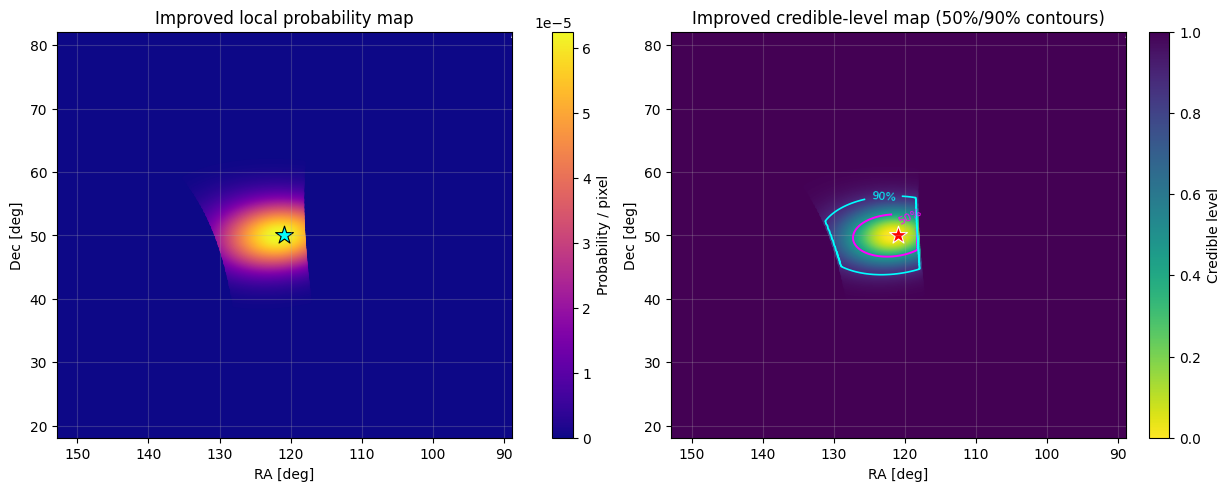

[timing] plotting: 7.61s
Output map nside: 1024
Best localization pixel: RA=121.626 deg, Dec=49.994 deg
Best sampled point     : RA=120.889 deg, Dec=50.111 deg
Plot window: ±32.0 deg in RA, ±32.0 deg in Dec
Local 50% pixels: 9889
Local 90% pixels: 26433
[timing] total: 172.50s


In [12]:
# Wider plotting window
t0 = time.perf_counter()
plot_ra_half = 32.0
plot_dec_half = 32.0

dra_plot_full = ((ra_out - ra0 + 180.0) % 360.0) - 180.0
plot_mask = (np.abs(dra_plot_full) <= plot_ra_half) & (np.abs(dec_out - dec0) <= plot_dec_half)

ra_plot = ra_out[plot_mask]
dec_plot = dec_out[plot_mask]
prob_plot = prob_map_imp[plot_mask]
perc_plot = perc_map_imp[plot_mask]

order = np.argsort(prob_plot)
ra_plot, dec_plot = ra_plot[order], dec_plot[order]
prob_plot, perc_plot = prob_plot[order], perc_plot[order]

m50 = perc_plot <= 0.50
m90 = perc_plot <= 0.90

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.2, 4.8), constrained_layout=True)

sc1 = ax1.scatter(ra_plot, dec_plot, c=prob_plot, s=6, cmap='plasma')
ax1.scatter([ra0], [dec0], marker='*', s=180, color='cyan', edgecolors='black', linewidths=0.8)
ax1.set_title('Improved local probability map')
ax1.set_xlabel('RA [deg]')
ax1.set_ylabel('Dec [deg]')
ax1.set_xlim(ra0 - plot_ra_half, ra0 + plot_ra_half)
ax1.set_ylim(dec0 - plot_dec_half, dec0 + plot_dec_half)
ax1.invert_xaxis()
ax1.grid(alpha=0.25)
fig.colorbar(sc1, ax=ax1, label='Probability / pixel')

sc2 = ax2.scatter(ra_plot, dec_plot, c=perc_plot, s=6, cmap='viridis_r', vmin=0.0, vmax=1.0)
ax2.scatter([ra0], [dec0], marker='*', s=180, color='red', edgecolors='white', linewidths=0.8)
try:
    cs = ax2.tricontour(
        ra_plot, dec_plot, perc_plot,
        levels=[0.50, 0.90],
        colors=['magenta', 'cyan'],
        linewidths=[1.4, 1.2],
    )
    ax2.clabel(cs, fmt={0.5: '50%', 0.9: '90%'}, fontsize=8)
except Exception:
    pass
ax2.set_title('Improved credible-level map (50%/90% contours)')
ax2.set_xlabel('RA [deg]')
ax2.set_ylabel('Dec [deg]')
ax2.set_xlim(ra0 - plot_ra_half, ra0 + plot_ra_half)
ax2.set_ylim(dec0 - plot_dec_half, dec0 + plot_dec_half)
ax2.invert_xaxis()
ax2.grid(alpha=0.25)
fig.colorbar(sc2, ax=ax2, label='Credible level')

plt.show()
print(f'[timing] plotting: {time.perf_counter()-t0:.2f}s')

best_pix = int(np.argmax(prob_map_imp))
best_ra, best_dec = hp.pix2ang(nside_out, best_pix, lonlat=True, nest=True)
print(f'Output map nside: {nside_out}')
print(f'Best localization pixel: RA={best_ra:.3f} deg, Dec={best_dec:.3f} deg')
print(f'Best sampled point     : RA={ra0:.3f} deg, Dec={dec0:.3f} deg')
print(f'Plot window: ±{plot_ra_half:.1f} deg in RA, ±{plot_dec_half:.1f} deg in Dec')
print(f'Local 50% pixels: {np.sum(m50)}')
print(f'Local 90% pixels: {np.sum(m90)}')
print(f'[timing] total: {time.perf_counter()-t_all0:.2f}s')